In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [100]:
df = pd.read_csv('/Users/mac/Desktop/projects/zoomcamp_ml/2025_ml/course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [101]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [102]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [103]:
categorical_df = df.select_dtypes(include=['object'])
numerical_df = df.select_dtypes(include=['int64', 'float64'])
numerical_df

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
0,1,79450.0,4,0.94,1
1,1,46992.0,1,0.80,0
2,5,78796.0,3,0.69,1
3,2,83843.0,1,0.87,0
4,3,85012.0,3,0.62,1
...,...,...,...,...,...
1457,1,NaN,4,0.53,1
1458,3,65259.0,2,0.24,1
1459,1,45688.0,3,0.02,1
1460,5,71016.0,0,0.25,1


In [104]:
cat_columns = categorical_df.columns
num_columns = numerical_df.columns
df[cat_columns] = df[cat_columns].fillna('NA')
df[num_columns] = df[num_columns].fillna(0.0)
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [105]:
df['industry'].mode()

0    retail
Name: industry, dtype: object

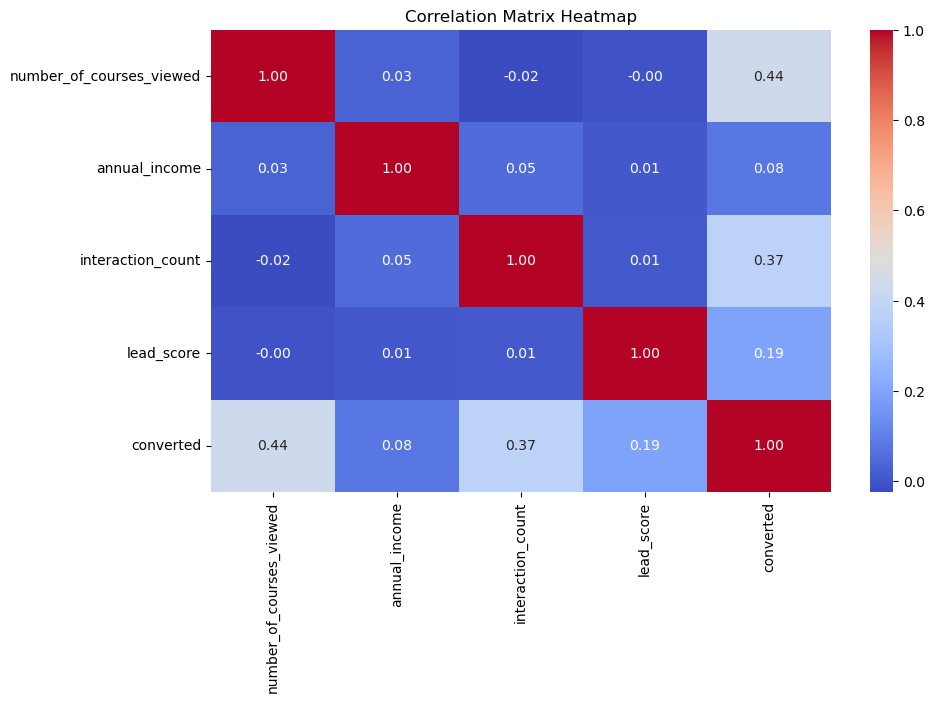

In [106]:

plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [107]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
len(df_train), len(df_test), len(df_val)

(876, 293, 293)

In [108]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values


del df_train['converted']
del df_val['converted']
del df_test['converted']

In [109]:
df_train.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,paid_ads,retail,0,58472.0,student,middle_east,5,0.03
1,organic_search,manufacturing,3,71738.0,student,middle_east,6,0.77
2,paid_ads,technology,3,81973.0,employed,north_america,2,0.59
3,NA,technology,1,74956.0,employed,europe,3,0.34
4,organic_search,retail,3,59335.0,student,australia,1,0.98


* Mutual Information of Variables

In [110]:
from sklearn.metrics import mutual_info_score

def mutual_info_y(series):
    return mutual_info_score(series, df_full_train.converted)

In [111]:
mutual_score = df_full_train[cat_columns].apply(mutual_info_y)
mutual_score= round(mutual_score,2)
mutual_score

lead_source          0.03
industry             0.01
employment_status    0.01
location             0.00
dtype: float64

* One Hot Encoding

In [112]:
dicts_train = df_train.to_dict(orient='records')
dicts_train

[{'lead_source': 'paid_ads',
  'industry': 'retail',
  'number_of_courses_viewed': 0,
  'annual_income': 58472.0,
  'employment_status': 'student',
  'location': 'middle_east',
  'interaction_count': 5,
  'lead_score': 0.03},
 {'lead_source': 'organic_search',
  'industry': 'manufacturing',
  'number_of_courses_viewed': 3,
  'annual_income': 71738.0,
  'employment_status': 'student',
  'location': 'middle_east',
  'interaction_count': 6,
  'lead_score': 0.77},
 {'lead_source': 'paid_ads',
  'industry': 'technology',
  'number_of_courses_viewed': 3,
  'annual_income': 81973.0,
  'employment_status': 'employed',
  'location': 'north_america',
  'interaction_count': 2,
  'lead_score': 0.59},
 {'lead_source': 'NA',
  'industry': 'technology',
  'number_of_courses_viewed': 1,
  'annual_income': 74956.0,
  'employment_status': 'employed',
  'location': 'europe',
  'interaction_count': 3,
  'lead_score': 0.34},
 {'lead_source': 'organic_search',
  'industry': 'retail',
  'number_of_courses_vi

In [113]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(dicts_train)
X_train[:1]

array([[5.8472e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 5.0000e+00,
        3.0000e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00]])

In [114]:
df_train[:1]

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,paid_ads,retail,0,58472.0,student,middle_east,5,0.03


In [115]:
dv.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [116]:
val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)
X_val[:1]

array([[5.222e+04, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 7.000e-02, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        3.000e+00]])

## Modeling and Predictions

In [117]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

accuracy = round(accuracy_score(y_val, y_pred), 2)

print(accuracy)

0.7


## Feature Elimination

In [118]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

original_accuracy = accuracy_score(y_val, y_pred)

# print(original_accuracy)

feature_names = df_train.columns

accuracy_diffs = {}

# Feature elimination loop
for i, feature in enumerate(feature_names):
    # Remove column `i`
    X_train_new = np.delete(X_train, i, axis=1)
    X_val_new = np.delete(X_val, i, axis=1)
    
    # Train model without this feature
    model.fit(X_train_new, y_train)
    y_pred_new = model.predict(X_val_new)
    
    # Calculate accuracy
    new_accuracy = accuracy_score(y_val, y_pred_new)
    
    # Store accuracy difference
    accuracy_diffs[feature] = original_accuracy - new_accuracy

# Print feature importance results
for feature, diff in accuracy_diffs.items():
    print(f"Feature: {feature}, Accuracy Difference: {diff:.5f}")

# Identify the least useful feature
least_useful_feature = min(accuracy_diffs, key=accuracy_diffs.get)
print(f"\nLeast Useful Feature: {least_useful_feature}")

Feature: lead_source, Accuracy Difference: -0.15358
Feature: industry, Accuracy Difference: 0.00000
Feature: number_of_courses_viewed, Accuracy Difference: 0.00000
Feature: annual_income, Accuracy Difference: 0.00000
Feature: employment_status, Accuracy Difference: 0.00000
Feature: location, Accuracy Difference: 0.00341
Feature: interaction_count, Accuracy Difference: 0.00000
Feature: lead_score, Accuracy Difference: 0.00000

Least Useful Feature: lead_source


## Regularized Logistic Regression

In [119]:
parameter = [0.01, 0.1, 1, 10, 100]

for c in parameter:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    accuracy = round(accuracy_score(y_val, y_pred), 2)

    print(f"C: {c}, Accuracy: {accuracy}")

C: 0.01, Accuracy: 0.7
C: 0.1, Accuracy: 0.7
C: 1, Accuracy: 0.7
C: 10, Accuracy: 0.7
C: 100, Accuracy: 0.7
